In [1]:
print("ali")

ali


In [2]:
!pip install numpy
!pip install pandas

In [3]:
# Install PyTorch, Torchaudio, and the Hugging Face library for WavLM
!pip install torch torchaudio transformers

# Install TensorFlow and Keras for the classifier
!pip install tensorflow keras

In [4]:
!pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pycparser-2.23-py3-none-any.whl.metadata (993 bytes)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 3.4 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.7 MB 5.2 MB/s eta 0:00:01
   ----------------------------

In [6]:
!pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.9.1
Uninstalling torch-2.9.1:
  Successfully uninstalled torch-2.9.1
Found existing installation: torchaudio 2.9.1
Uninstalling torchaudio-2.9.1:
  Successfully uninstalled torchaudio-2.9.1


You can safely remove it manually.


In [7]:
!pip show torch


In [8]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 39.6 MB/s eta 0:01:02
     ---------------------------------------- 0.0/2.4 GB 48.8 MB/s eta 0:00:50
     ---------------------------------------- 0.0/2.4 GB 46.7 MB/s eta 0:00:52
      --------------------------------------- 0.0/2.4 GB 46.3 MB/s eta 0:00:53
      --------------------------------------- 0.0/2.4 GB 49.0 MB/s eta 0:00:49
     - -------------------------------------- 0.1/2.4 GB 52.3 MB/s eta 0:00:46
     - -------------------------------------- 0.1/2.4 GB 52.4 MB/s eta 0:00:46
     - -------------------------------------- 0.1/2.4 GB 52.9 MB/s eta 0:00:45
     - -------------------------------------- 0.1/2.4 GB 53.5 MB/s eta 0:00:44
     - -------------------------------------- 0.1/2.4 GB 55.0 MB/s eta 0:00:43
     -- ------------------------------------- 0.1/2.4 GB 55.0 MB/s eta 0:00:43
 

In [11]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.1.0+cu121 torchvision==0.16.0+cu121 torchaudio==2.1.0+cu121 --index-url https://download.pytorch.org/whl/cu121


Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.5 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.5 GB 1.5 MB/s eta 0:27:03
     ---------------------------------------- 0.0/2.5 GB 3.2 MB/s eta 0:12:48
     ---------------------------------------- 0.0/2.5 GB 3.6 MB/s eta 0:11:22
     ----------

In [7]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.9.1+cpu
False


In [13]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
from transformers import WavLMForXVector, AutoFeatureExtractor

from tqdm.notebook import tqdm


In [12]:
import os
import numpy as np
import pandas as pd
import torch
import librosa
from transformers import AutoFeatureExtractor, WavLMForXVector
from tqdm import tqdm

# --- Configuration (UPDATE THESE PATHS) ---
# Set the root folder where your LA folder is located
# IMPORTANT: Use raw strings (r'...') or double backslashes for Windows paths
DATASET_ROOT = r'la_dataset\LA' 
# Assuming the protocol is for TRAIN (trn.txt)
PROTOCOL_FILE = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.train.trn.txt')

# Output file path 
OUTPUT_FILE = 'wavlm_features_LA_TRAIN.npz'

# WavLM Parameters
MODEL_NAME = "microsoft/wavlm-base-plus" 
SAMPLE_RATE = 16000 # WavLM requires 16kHz
DURATION = 3.0 # Process first 3 seconds of audio

# --- 1. Load Model and Processor ---
# Use CUDA if available (crucial for speed!)
device = "cuda" if torch.cuda.is_available() else "cpu" 

processor = AutoFeatureExtractor.from_pretrained(MODEL_NAME) 
model = WavLMForXVector.from_pretrained(MODEL_NAME).to(device)
model.eval() 

print(f"Loaded WavLM model on device: **{device}**. Starting feature extraction...")

# --- 2. Protocol Parsing Function (CORRECTED) ---
def parse_protocol(protocol_path, root_path):
    """
    Parses the ASVspoof protocol file.
    FIXED: Extracts split code from the SECOND column (file_id), not the first (speaker_id).
    """
    data = []

    # Map the split code (T/D/E) to the actual subdirectory path
    subdir_map = {
        'T': os.path.join(root_path, 'ASVspoof2019_LA_train', 'flac'),
        'D': os.path.join(root_path, 'ASVspoof2019_LA_dev', 'flac'),
        'E': os.path.join(root_path, 'ASVspoof2019_LA_eval', 'flac')
    }

    try:
        with open(protocol_path, 'r') as f:
            for line in f:
                parts = line.strip().split()

                # Example line: LA_0079 LA_T_1138215 - - bonafide
                # parts[0] = speaker_id (LA_0079)
                # parts[1] = file_id (LA_T_1138215) <- This contains the split code!
                # parts[-1] = label (bonafide/spoof)
                
                # Extract split code from the SECOND column (file_id)
                file_id_full = parts[1]  # e.g., LA_T_1138215
                split_code = file_id_full.split('_')[1]  # Extracts 'T', 'D', or 'E'
                
                label = 1 if parts[-1].lower() == "bonafide" else 0 

                # Build the file path
                file_path = os.path.join(subdir_map[split_code], file_id_full + ".flac")

                data.append({
                    "file_path": file_path,
                    "label": label
                })
    except FileNotFoundError:
        print(f"Error: Protocol file not found at {protocol_path}")
        return pd.DataFrame()
    except (IndexError, KeyError) as e:
        print(f"Error parsing protocol line: {line.strip()}")
        print(f"Error details: {e}")
        return pd.DataFrame()

    return pd.DataFrame(data)

# --- 3. Feature Extraction Function ---
def extract_wavlm_features(file_path):
    """Loads audio, processes it, and extracts the WavLM X-Vector embedding."""
    try:
        speech, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        
        inputs = processor(
            speech, 
            sampling_rate=SAMPLE_RATE, 
            return_tensors="pt"
        )
        
        with torch.no_grad():
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
        
        # X-Vector is the single pooled embedding
        embedding = outputs.embeddings.squeeze().cpu().numpy() 
        return embedding
        
    except FileNotFoundError:
        # print(f"Skipping file: {file_path} (File not found)")
        return None
    except Exception as e:
        # print(f"Error processing file {file_path}: {e}")
        return None

# --- 4. Main Execution ---
df_protocol = parse_protocol(PROTOCOL_FILE, DATASET_ROOT)

X_features = []
y_labels = []

if not df_protocol.empty:
    for index, row in tqdm(df_protocol.iterrows(), total=len(df_protocol), desc="Extracting WavLM Features"):
        feature = extract_wavlm_features(row['file_path'])
        
        if feature is not None:
            X_features.append(feature)
            y_labels.append(row['label'])

    X_features = np.array(X_features)
    y_labels = np.array(y_labels)

    # Save the features and labels
    np.savez_compressed(OUTPUT_FILE, X=X_features, y=y_labels)

    print("\n--- Feature Extraction Complete ---")
    print(f"Total features extracted: **{len(X_features)}**")
    print(f"Feature matrix shape: **{X_features.shape}**")
    print(f"Saved features and labels to: **{OUTPUT_FILE}**")
else:
    print("\n--- Execution Aborted ---")
    print("No data extracted from the protocol file. Check file paths and format.")

Some weights of WavLMForXVector were not initialized from the model checkpoint at microsoft/wavlm-base-plus and are newly initialized: ['classifier.bias', 'classifier.weight', 'feature_extractor.bias', 'feature_extractor.weight', 'objective.weight', 'projector.bias', 'projector.weight', 'tdnn.0.kernel.bias', 'tdnn.0.kernel.weight', 'tdnn.1.kernel.bias', 'tdnn.1.kernel.weight', 'tdnn.2.kernel.bias', 'tdnn.2.kernel.weight', 'tdnn.3.kernel.bias', 'tdnn.3.kernel.weight', 'tdnn.4.kernel.bias', 'tdnn.4.kernel.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded WavLM model on device: **cpu**. Starting feature extraction...


Extracting WavLM Features:   0%|          | 0/25380 [00:00<?, ?it/s]c:\Users\22K-4699\Desktop\fyp\.conda\Lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
Extracting WavLM Features: 100%|██████████| 25380/25380 [1:01:29<00:00,  6.88it/s]



--- Feature Extraction Complete ---
Total features extracted: **25380**
Feature matrix shape: **(25380, 512)**
Saved features and labels to: **wavlm_features_LA_TRAIN.npz**


In [15]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")




PyTorch version: 2.9.1+cpu
CUDA available: False
CUDA version: None


In [17]:
import os
import numpy as np
import pandas as pd
import torch
import librosa
from transformers import AutoFeatureExtractor, WavLMForXVector
from tqdm import tqdm

# --- Configuration (UPDATE THESE PATHS) ---
# Set the root folder where your LA folder is located
# IMPORTANT: Use raw strings (r'...') or double backslashes for Windows paths
DATASET_ROOT = r'la_dataset\LA' 
# Assuming the protocol is for TRAIN (trn.txt)



PROTOCOL_FILE = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.dev.trl.txt')
OUTPUT_FILE = 'wavlm_features_LA_DEV.npz'



# WavLM Parameters
MODEL_NAME = "microsoft/wavlm-base-plus" 
SAMPLE_RATE = 16000 # WavLM requires 16kHz
DURATION = 3.0 # Process first 3 seconds of audio

# --- 1. Load Model and Processor ---
# Use CUDA if available (crucial for speed!)
device = "cuda" if torch.cuda.is_available() else "cpu" 

processor = AutoFeatureExtractor.from_pretrained(MODEL_NAME) 
model = WavLMForXVector.from_pretrained(MODEL_NAME, use_safetensors=True).to(device)
model.eval() 

print(f"Loaded WavLM model on device: **{device}**. Starting feature extraction...")

# --- 2. Protocol Parsing Function (CORRECTED) ---
def parse_protocol(protocol_path, root_path):
    """
    Parses the ASVspoof protocol file.
    FIXED: Extracts split code from the SECOND column (file_id), not the first (speaker_id).
    """
    data = []

    # Map the split code (T/D/E) to the actual subdirectory path
    subdir_map = {
        'T': os.path.join(root_path, 'ASVspoof2019_LA_train', 'flac'),
        'D': os.path.join(root_path, 'ASVspoof2019_LA_dev', 'flac'),
        'E': os.path.join(root_path, 'ASVspoof2019_LA_eval', 'flac')
    }

    try:
        with open(protocol_path, 'r') as f:
            for line in f:
                parts = line.strip().split()

                # Example line: LA_0079 LA_T_1138215 - - bonafide
                # parts[0] = speaker_id (LA_0079)
                # parts[1] = file_id (LA_T_1138215) <- This contains the split code!
                # parts[-1] = label (bonafide/spoof)
                
                # Extract split code from the SECOND column (file_id)
                file_id_full = parts[1]  # e.g., LA_T_1138215
                split_code = file_id_full.split('_')[1]  # Extracts 'T', 'D', or 'E'
                
                label = 1 if parts[-1].lower() == "bonafide" else 0 

                # Build the file path
                file_path = os.path.join(subdir_map[split_code], file_id_full + ".flac")

                data.append({
                    "file_path": file_path,
                    "label": label
                })
    except FileNotFoundError:
        print(f"Error: Protocol file not found at {protocol_path}")
        return pd.DataFrame()
    except (IndexError, KeyError) as e:
        print(f"Error parsing protocol line: {line.strip()}")
        print(f"Error details: {e}")
        return pd.DataFrame()

    return pd.DataFrame(data)

# --- 3. Feature Extraction Function ---
def extract_wavlm_features(file_path):
    """Loads audio, processes it, and extracts the WavLM X-Vector embedding."""
    try:
        speech, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        
        inputs = processor(
            speech, 
            sampling_rate=SAMPLE_RATE, 
            return_tensors="pt"
        )
        
        with torch.no_grad():
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
        
        # X-Vector is the single pooled embedding
        embedding = outputs.embeddings.squeeze().cpu().numpy() 
        return embedding
        
    except FileNotFoundError:
        # print(f"Skipping file: {file_path} (File not found)")
        return None
    except Exception as e:
        # print(f"Error processing file {file_path}: {e}")
        return None

# --- 4. Main Execution ---
df_protocol = parse_protocol(PROTOCOL_FILE, DATASET_ROOT)

X_features = []
y_labels = []

if not df_protocol.empty:
    for index, row in tqdm(df_protocol.iterrows(), total=len(df_protocol), desc="Extracting WavLM Features"):
        feature = extract_wavlm_features(row['file_path'])
        
        if feature is not None:
            X_features.append(feature)
            y_labels.append(row['label'])

    X_features = np.array(X_features)
    y_labels = np.array(y_labels)

    # Save the features and labels
    np.savez_compressed(OUTPUT_FILE, X=X_features, y=y_labels)

    print("\n--- Feature Extraction Complete ---")
    print(f"Total features extracted: **{len(X_features)}**")
    print(f"Feature matrix shape: **{X_features.shape}**")
    print(f"Saved features and labels to: **{OUTPUT_FILE}**")
else:
    print("\n--- Execution Aborted ---")
    print("No data extracted from the protocol file. Check file paths and format.")

Some weights of WavLMForXVector were not initialized from the model checkpoint at microsoft/wavlm-base-plus and are newly initialized: ['classifier.bias', 'classifier.weight', 'feature_extractor.bias', 'feature_extractor.weight', 'objective.weight', 'projector.bias', 'projector.weight', 'tdnn.0.kernel.bias', 'tdnn.0.kernel.weight', 'tdnn.1.kernel.bias', 'tdnn.1.kernel.weight', 'tdnn.2.kernel.bias', 'tdnn.2.kernel.weight', 'tdnn.3.kernel.bias', 'tdnn.3.kernel.weight', 'tdnn.4.kernel.bias', 'tdnn.4.kernel.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded WavLM model on device: **cpu**. Starting feature extraction...


Extracting WavLM Features:   0%|          | 0/24844 [00:00<?, ?it/s]c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
Extracting WavLM Features: 100%|██████████| 24844/24844 [48:39<00:00,  8.51it/s] 



--- Feature Extraction Complete ---
Total features extracted: **24844**
Feature matrix shape: **(24844, 512)**
Saved features and labels to: **wavlm_features_LA_DEV.npz**


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import librosa
from transformers import AutoFeatureExtractor, WavLMForXVector
from tqdm import tqdm

c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


# --- Configuration (UPDATE THESE PATHS) ---
# Set the root folder where your LA folder is located
# IMPORTANT: Use raw strings (r'...') or double backslashes for Windows paths
DATASET_ROOT = r'la_dataset\LA' 
# Assuming the protocol is for TRAIN (trn.txt)



PROTOCOL_FILE = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.eval.trl.txt')
OUTPUT_FILE = 'wavlm_features_LA_EVAL.npz'



# WavLM Parameters
MODEL_NAME = "microsoft/wavlm-base-plus" 
SAMPLE_RATE = 16000 # WavLM requires 16kHz
DURATION = 3.0 # Process first 3 seconds of audio

# --- 1. Load Model and Processor ---
# Use CUDA if available (crucial for speed!)
device = "cuda" if torch.cuda.is_available() else "cpu" 

processor = AutoFeatureExtractor.from_pretrained(MODEL_NAME) 
model = WavLMForXVector.from_pretrained(MODEL_NAME, use_safetensors=True).to(device)
model.eval() 

print(f"Loaded WavLM model on device: **{device}**. Starting feature extraction...")

# --- 2. Protocol Parsing Function (CORRECTED) ---
def parse_protocol(protocol_path, root_path):
    """
    Parses the ASVspoof protocol file.
    FIXED: Extracts split code from the SECOND column (file_id), not the first (speaker_id).
    """
    data = []

    # Map the split code (T/D/E) to the actual subdirectory path
    subdir_map = {
        'T': os.path.join(root_path, 'ASVspoof2019_LA_train', 'flac'),
        'D': os.path.join(root_path, 'ASVspoof2019_LA_dev', 'flac'),
        'E': os.path.join(root_path, 'ASVspoof2019_LA_eval', 'flac')
    }

    try:
        with open(protocol_path, 'r') as f:
            for line in f:
                parts = line.strip().split()

                # Example line: LA_0079 LA_T_1138215 - - bonafide
                # parts[0] = speaker_id (LA_0079)
                # parts[1] = file_id (LA_T_1138215) <- This contains the split code!
                # parts[-1] = label (bonafide/spoof)
                
                # Extract split code from the SECOND column (file_id)
                file_id_full = parts[1]  # e.g., LA_T_1138215
                split_code = file_id_full.split('_')[1]  # Extracts 'T', 'D', or 'E'
                
                label = 1 if parts[-1].lower() == "bonafide" else 0 

                # Build the file path
                file_path = os.path.join(subdir_map[split_code], file_id_full + ".flac")

                data.append({
                    "file_path": file_path,
                    "label": label
                })
    except FileNotFoundError:
        print(f"Error: Protocol file not found at {protocol_path}")
        return pd.DataFrame()
    except (IndexError, KeyError) as e:
        print(f"Error parsing protocol line: {line.strip()}")
        print(f"Error details: {e}")
        return pd.DataFrame()

    return pd.DataFrame(data)

# --- 3. Feature Extraction Function ---
def extract_wavlm_features(file_path):
    """Loads audio, processes it, and extracts the WavLM X-Vector embedding."""
    try:
        speech, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        
        inputs = processor(
            speech, 
            sampling_rate=SAMPLE_RATE, 
            return_tensors="pt"
        )
        
        with torch.no_grad():
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
        
        # X-Vector is the single pooled embedding
        embedding = outputs.embeddings.squeeze().cpu().numpy() 
        return embedding
        
    except FileNotFoundError:
        # print(f"Skipping file: {file_path} (File not found)")
        return None
    except Exception as e:
        # print(f"Error processing file {file_path}: {e}")
        return None

# --- 4. Main Execution ---
df_protocol = parse_protocol(PROTOCOL_FILE, DATASET_ROOT)

X_features = []
y_labels = []

if not df_protocol.empty:
    for index, row in tqdm(df_protocol.iterrows(), total=len(df_protocol), desc="Extracting WavLM Features"):
        feature = extract_wavlm_features(row['file_path'])
        
        if feature is not None:
            X_features.append(feature)
            y_labels.append(row['label'])

    X_features = np.array(X_features)
    y_labels = np.array(y_labels)

    # Save the features and labels
    np.savez_compressed(OUTPUT_FILE, X=X_features, y=y_labels)

    print("\n--- Feature Extraction Complete ---")
    print(f"Total features extracted: **{len(X_features)}**")
    print(f"Feature matrix shape: **{X_features.shape}**")
    print(f"Saved features and labels to: **{OUTPUT_FILE}**")
else:
    print("\n--- Execution Aborted ---")
    print("No data extracted from the protocol file. Check file paths and format.")

Some weights of WavLMForXVector were not initialized from the model checkpoint at microsoft/wavlm-base-plus and are newly initialized: ['classifier.bias', 'classifier.weight', 'feature_extractor.bias', 'feature_extractor.weight', 'objective.weight', 'projector.bias', 'projector.weight', 'tdnn.0.kernel.bias', 'tdnn.0.kernel.weight', 'tdnn.1.kernel.bias', 'tdnn.1.kernel.weight', 'tdnn.2.kernel.bias', 'tdnn.2.kernel.weight', 'tdnn.3.kernel.bias', 'tdnn.3.kernel.weight', 'tdnn.4.kernel.bias', 'tdnn.4.kernel.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded WavLM model on device: **cuda**. Starting feature extraction...


Extracting WavLM Features:   0%|          | 0/71237 [00:00<?, ?it/s]c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
Extracting WavLM Features: 100%|██████████| 71237/71237 [52:45<00:00, 22.51it/s]  



--- Feature Extraction Complete ---
Total features extracted: **71237**
Feature matrix shape: **(71237, 512)**
Saved features and labels to: **wavlm_features_LA_EVAL.npz**


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib



In [4]:
# --- Configuration ---
TRAIN_FILE = 'wavlm_features_LA_TRAIN.npz'
DEV_FILE = 'wavlm_features_LA_DEV.npz'
EVAL_FILE = 'wavlm_features_LA_EVAL.npz'

MODEL_SAVE_PATH = 'deepfake_detector_final.h5'
SCALER_SAVE_PATH = 'feature_scaler.pkl'

# --- 1. Load All Datasets ---
print("=" * 70)
print("LOADING DATASETS")
print("=" * 70)

print(f"\nLoading training data from {TRAIN_FILE}...")
train_data = np.load(TRAIN_FILE)
X_train = train_data['X']
y_train = train_data['y']
print(f"✓ Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")

print(f"\nLoading development data from {DEV_FILE}...")
dev_data = np.load(DEV_FILE)
X_dev = dev_data['X']
y_dev = dev_data['y']
print(f"✓ Development: {X_dev.shape[0]} samples, {X_dev.shape[1]} features")

print(f"\nLoading evaluation data from {EVAL_FILE}...")
eval_data = np.load(EVAL_FILE)
X_eval = eval_data['X']
y_eval = eval_data['y']
print(f"✓ Evaluation: {X_eval.shape[0]} samples, {X_eval.shape[1]} features")

# --- 2. Combine Training and Development Sets ---
print("\n" + "=" * 70)
print("COMBINING TRAIN + DEV FOR TRAINING")
print("=" * 70)

X_train_combined = np.concatenate([X_train, X_dev], axis=0)
y_train_combined = np.concatenate([y_train, y_dev], axis=0)

print(f"Combined training data: {X_train_combined.shape[0]} samples")
print(f"  - Bonafide: {np.sum(y_train_combined == 1)}")
print(f"  - Spoof: {np.sum(y_train_combined == 0)}")
print(f"  - Class ratio: {np.sum(y_train_combined == 0) / np.sum(y_train_combined == 1):.2f}:1 (spoof:bonafide)")

# --- 3. Feature Scaling ---
print("\n" + "=" * 70)
print("FEATURE SCALING")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_eval_scaled = scaler.transform(X_eval)  # Use same scaler, don't fit again!

# Save scaler for future inference
joblib.dump(scaler, SCALER_SAVE_PATH)
print(f"✓ Features scaled and scaler saved to {SCALER_SAVE_PATH}")

# --- 4. Convert Labels to One-Hot Encoding ---
y_train_encoded = to_categorical(y_train_combined, num_classes=2)
y_eval_encoded = to_categorical(y_eval, num_classes=2)

print(f"✓ Labels converted to one-hot encoding")

# --- 5. Split Combined Data for Validation ---
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train_encoded, 
    test_size=0.15,  # 15% for validation
    random_state=42, 
    stratify=y_train_combined
)

print(f"\nFinal split:")
print(f"  - Training: {X_train_final.shape[0]} samples")
print(f"  - Validation: {X_val.shape[0]} samples")
print(f"  - Evaluation (test): {X_eval_scaled.shape[0]} samples")

# --- 6. Build Model ---
print("\n" + "=" * 70)
print("BUILDING MODEL")
print("=" * 70)

input_dim = X_train_final.shape[1]  # Should be 512

model = Sequential([
    Dense(256, activation='relu', input_dim=input_dim),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    Dense(2, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --- 7. Define Callbacks ---
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_checkpoint.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# --- 8. Train Model ---
print("\n" + "=" * 70)
print("TRAINING MODEL")
print("=" * 70)

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# --- 9. Save Final Model ---
model.save(MODEL_SAVE_PATH)

LOADING DATASETS

Loading training data from wavlm_features_LA_TRAIN.npz...


FileNotFoundError: [Errno 2] No such file or directory: 'wavlm_features_LA_TRAIN.npz'

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


EVALUATION ON TEST SET (EVAL)
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step

Test Loss: 6.0119
Test Accuracy: 0.8968

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

       Spoof     0.8968    1.0000    0.9456     63882
    Bonafide     0.0000    0.0000    0.0000      7355

    accuracy                         0.8968     71237
   macro avg     0.4484    0.5000    0.4728     71237
weighted avg     0.8042    0.8968    0.8479     71237


----------------------------------------------------------------------
CONFUSION MATRIX
----------------------------------------------------------------------
                Predicted
              Spoof  Bonafide
Actual Spoof     63882       0
       Bonafide   7355       0

ROC-AUC Score: 0.3648

GENERATING PLOTS


c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

✓ Plots saved to training_results.png


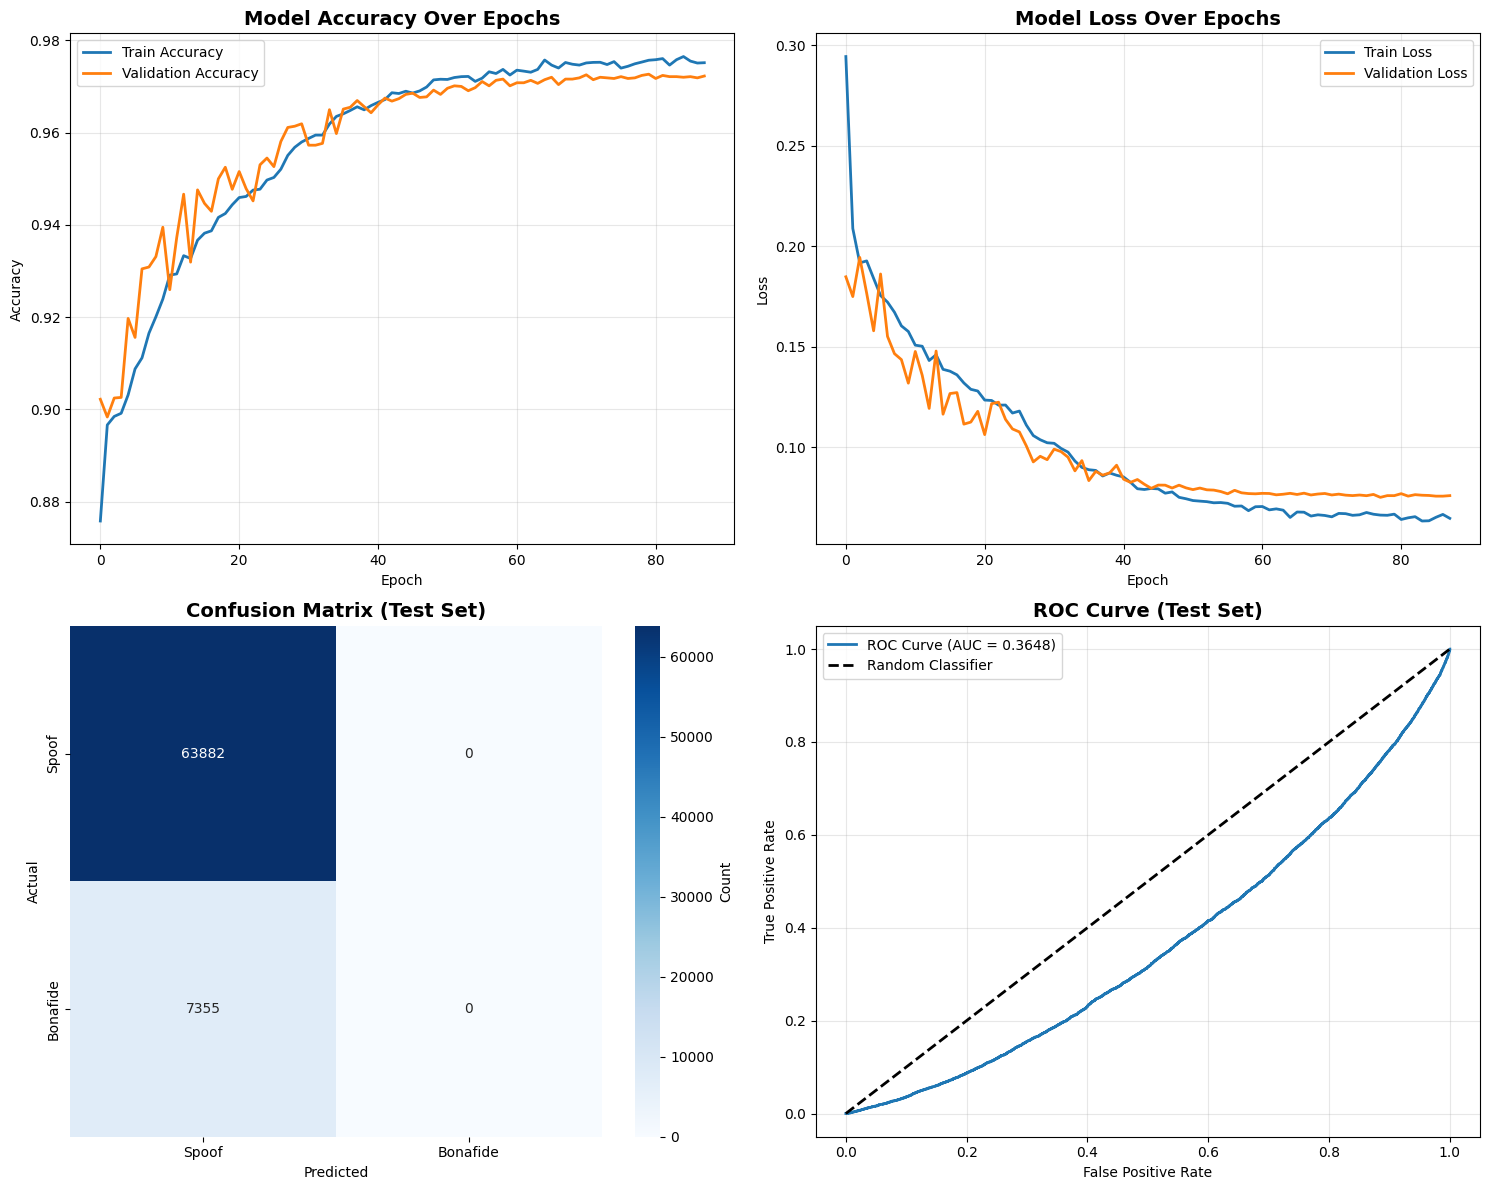


TRAINING COMPLETE - SUMMARY
✓ Model trained on 50224 samples (Train + Dev)
✓ Validated on 7534 samples
✓ Tested on 71237 samples (Eval set)
✓ Final Test Accuracy: 0.8968
✓ ROC-AUC Score: 0.3648
✓ Model saved: deepfake_detector_final.h5
✓ Scaler saved: feature_scaler.pkl


In [10]:
# --- 10. Evaluate on Test Set (EVAL) ---
print("\n" + "=" * 70)
print("EVALUATION ON TEST SET (EVAL)")
print("=" * 70)

# Predictions
y_eval_pred_probs = model.predict(X_eval_scaled)
y_eval_pred = np.argmax(y_eval_pred_probs, axis=1)

# Calculate metrics
eval_loss, eval_accuracy = model.evaluate(X_eval_scaled, y_eval_encoded, verbose=0)
print(f"\nTest Loss: {eval_loss:.4f}")
print(f"Test Accuracy: {eval_accuracy:.4f}")

# Classification Report
print("\n" + "-" * 70)
print("CLASSIFICATION REPORT")
print("-" * 70)
print(classification_report(
    y_eval, 
    y_eval_pred, 
    target_names=['Spoof', 'Bonafide'],
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_eval, y_eval_pred)
print("\n" + "-" * 70)
print("CONFUSION MATRIX")
print("-" * 70)
print(f"                Predicted")
print(f"              Spoof  Bonafide")
print(f"Actual Spoof    {cm[0][0]:6d}  {cm[0][1]:6d}")
print(f"       Bonafide {cm[1][0]:6d}  {cm[1][1]:6d}")

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_eval, y_eval_pred_probs[:, 1])
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# --- 11. Plot Training History ---
print("\n" + "=" * 70)
print("GENERATING PLOTS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Training & Validation Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training & Validation Loss
axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Spoof', 'Bonafide'],
            yticklabels=['Spoof', 'Bonafide'],
            ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xlabel('Predicted')

# Plot 4: ROC Curve
fpr, tpr, thresholds = roc_curve(y_eval, y_eval_pred_probs[:, 1])
axes[1, 1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
axes[1, 1].set_title('ROC Curve (Test Set)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
print("✓ Plots saved to training_results.png")
plt.show()

# --- 12. Summary ---
print("\n" + "=" * 70)
print("TRAINING COMPLETE - SUMMARY")
print("=" * 70)
print(f"✓ Model trained on {X_train_combined.shape[0]} samples (Train + Dev)")
print(f"✓ Validated on {X_val.shape[0]} samples")
print(f"✓ Tested on {X_eval_scaled.shape[0]} samples (Eval set)")
print(f"✓ Final Test Accuracy: {eval_accuracy:.4f}")
print(f"✓ ROC-AUC Score: {roc_auc:.4f}")
print(f"✓ Model saved: {MODEL_SAVE_PATH}")
print(f"✓ Scaler saved: {SCALER_SAVE_PATH}")
print("=" * 70)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

# --- Configuration ---
TRAIN_FILE = 'wavlm_features_LA_TRAIN.npz'
DEV_FILE = 'wavlm_features_LA_DEV.npz'
EVAL_FILE = 'wavlm_features_LA_EVAL.npz'

MODEL_SAVE_PATH = 'deepfake_detector_improved.h5'
SCALER_SAVE_PATH = 'feature_scaler_improved.pkl'

print("=" * 70)
print("IMPROVED DEEPFAKE DETECTOR TRAINING")
print("=" * 70)

# --- 1. Load All Datasets ---
print("\n" + "=" * 70)
print("LOADING DATASETS")
print("=" * 70)

print(f"\nLoading training data from {TRAIN_FILE}...")
train_data = np.load(TRAIN_FILE)
X_train = train_data['X']
y_train = train_data['y']
print(f"✓ Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")

print(f"\nLoading development data from {DEV_FILE}...")
dev_data = np.load(DEV_FILE)
X_dev = dev_data['X']
y_dev = dev_data['y']
print(f"✓ Development: {X_dev.shape[0]} samples, {X_dev.shape[1]} features")

print(f"\nLoading evaluation data from {EVAL_FILE}...")
eval_data = np.load(EVAL_FILE)
X_eval = eval_data['X']
y_eval = eval_data['y']
print(f"✓ Evaluation: {X_eval.shape[0]} samples, {X_eval.shape[1]} features")

# --- 2. Diagnostic: Check Label Distribution ---
print("\n" + "=" * 70)
print("LABEL DISTRIBUTION ANALYSIS")
print("=" * 70)

print("\nTraining set:")
print(f"  Class 0 (Spoof): {np.sum(y_train == 0)} ({100*np.sum(y_train == 0)/len(y_train):.2f}%)")
print(f"  Class 1 (Bonafide): {np.sum(y_train == 1)} ({100*np.sum(y_train == 1)/len(y_train):.2f}%)")

print("\nDevelopment set:")
print(f"  Class 0 (Spoof): {np.sum(y_dev == 0)} ({100*np.sum(y_dev == 0)/len(y_dev):.2f}%)")
print(f"  Class 1 (Bonafide): {np.sum(y_dev == 1)} ({100*np.sum(y_dev == 1)/len(y_dev):.2f}%)")

print("\nEvaluation set:")
print(f"  Class 0 (Spoof): {np.sum(y_eval == 0)} ({100*np.sum(y_eval == 0)/len(y_eval):.2f}%)")
print(f"  Class 1 (Bonafide): {np.sum(y_eval == 1)} ({100*np.sum(y_eval == 1)/len(y_eval):.2f}%)")

# --- 3. Combine Training and Development Sets ---
print("\n" + "=" * 70)
print("COMBINING TRAIN + DEV FOR TRAINING")
print("=" * 70)

X_train_combined = np.concatenate([X_train, X_dev], axis=0)
y_train_combined = np.concatenate([y_train, y_dev], axis=0)

print(f"\nCombined training data: {X_train_combined.shape[0]} samples")
print(f"  - Class 0 (Spoof): {np.sum(y_train_combined == 0)}")
print(f"  - Class 1 (Bonafide): {np.sum(y_train_combined == 1)}")
print(f"  - Imbalance ratio: {np.sum(y_train_combined == 0) / np.sum(y_train_combined == 1):.2f}:1 (spoof:bonafide)")

# --- 4. Calculate Class Weights ---
print("\n" + "=" * 70)
print("CALCULATING CLASS WEIGHTS")
print("=" * 70)

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_combined),
    y=y_train_combined
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print(f"\nClass weights (to handle imbalance):")
print(f"  Class 0 (Spoof): {class_weight_dict[0]:.4f}")
print(f"  Class 1 (Bonafide): {class_weight_dict[1]:.4f}")

# --- 5. Feature Scaling ---
print("\n" + "=" * 70)
print("FEATURE SCALING")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_eval_scaled = scaler.transform(X_eval)

# Save scaler
joblib.dump(scaler, SCALER_SAVE_PATH)
print(f"✓ Features scaled and scaler saved to {SCALER_SAVE_PATH}")

print(f"\nFeature statistics after scaling:")
print(f"  Mean: {np.mean(X_train_scaled):.6f} (should be ~0)")
print(f"  Std: {np.std(X_train_scaled):.6f} (should be ~1)")

# --- 6. Convert Labels to One-Hot Encoding ---
y_train_encoded = to_categorical(y_train_combined, num_classes=2)
y_eval_encoded = to_categorical(y_eval, num_classes=2)

print(f"\n✓ Labels converted to one-hot encoding")

# --- 7. Split Combined Data for Validation ---
print("\n" + "=" * 70)
print("CREATING VALIDATION SPLIT")
print("=" * 70)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train_encoded, 
    test_size=0.15,
    random_state=42, 
    stratify=y_train_combined
)

print(f"\nFinal split:")
print(f"  - Training: {X_train_final.shape[0]} samples")
print(f"  - Validation: {X_val.shape[0]} samples")
print(f"  - Evaluation (test): {X_eval_scaled.shape[0]} samples")

# --- 8. Build Improved Model ---
print("\n" + "=" * 70)
print("BUILDING IMPROVED MODEL")
print("=" * 70)

input_dim = X_train_final.shape[1]

# Simpler, more robust architecture
model = Sequential([
    Dense(256, activation='relu', input_dim=input_dim, 
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(128, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(64, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    
    Dense(2, activation='softmax')
])

# Compile with lower learning rate and AUC metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\nModel Architecture:")
model.summary()

# --- 9. Define Callbacks ---
print("\n" + "=" * 70)
print("SETTING UP CALLBACKS")
print("=" * 70)

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=15,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_checkpoint_improved.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    )
]

print("✓ Callbacks configured:")
print("  - EarlyStopping: monitor val_auc, patience=15")
print("  - ModelCheckpoint: save best model based on val_auc")
print("  - ReduceLROnPlateau: reduce LR when val_loss plateaus")

# --- 10. Train Model with Class Weights ---
print("\n" + "=" * 70)
print("TRAINING MODEL")
print("=" * 70)

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,  # IMPORTANT: Handle class imbalance
    callbacks=callbacks,
    verbose=1
)

# --- 11. Save Final Model ---
model.save(MODEL_SAVE_PATH)
print(f"\n✓ Model saved to {MODEL_SAVE_PATH}")

# --- 12. Evaluate on Test Set ---
print("\n" + "=" * 70)
print("EVALUATING ON TEST SET")
print("=" * 70)

# Get predictions
y_pred_probs = model.predict(X_eval_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_eval_encoded, axis=1)

# Calculate metrics
test_loss, test_acc, test_auc, test_precision, test_recall = model.evaluate(
    X_eval_scaled, y_eval_encoded, verbose=0
)

print(f"\nTest Set Performance:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  AUC: {test_auc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  Loss: {test_loss:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(
    y_true_classes, y_pred_classes,
    target_names=['Spoof', 'Bonafide'],
    digits=4
))

# --- 13. Visualization ---
print("\n" + "=" * 70)
print("GENERATING VISUALIZATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Improved Model Training Results', fontsize=16, fontweight='bold')

# 1. Training & Validation Accuracy
ax1 = axes[0, 0]
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Training & Validation Loss
ax2 = axes[0, 1]
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix
ax3 = axes[1, 0]
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, 
            xticklabels=['Spoof', 'Bonafide'],
            yticklabels=['Spoof', 'Bonafide'],
            cbar_kws={'label': 'Count'})
ax3.set_xlabel('Predicted', fontsize=12)
ax3.set_ylabel('Actual', fontsize=12)
ax3.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')

# 4. ROC Curve
ax4 = axes[1, 1]
fpr, tpr, _ = roc_curve(y_true_classes, y_pred_probs[:, 1])
roc_auc = roc_auc_score(y_true_classes, y_pred_probs[:, 1])
ax4.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
ax4.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
ax4.set_xlabel('False Positive Rate', fontsize=12)
ax4.set_ylabel('True Positive Rate', fontsize=12)
ax4.set_title('ROC Curve (Test Set)', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('improved_training_results.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Visualization saved to 'improved_training_results.png'")

# --- 14. AUC Over Epochs ---
if 'auc' in history.history:
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['auc'], label='Train AUC', linewidth=2)
    plt.plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('AUC', fontsize=12)
    plt.title('Model AUC Over Epochs', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('auc_over_epochs.png', dpi=300, bbox_inches='tight')
    print(f"✓ AUC plot saved to 'auc_over_epochs.png'")

# --- 15. Final Summary ---
print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(f"\nFiles saved:")
print(f"  - Model: {MODEL_SAVE_PATH}")
print(f"  - Scaler: {SCALER_SAVE_PATH}")
print(f"  - Best checkpoint: best_model_checkpoint_improved.h5")
print(f"  - Visualizations: improved_training_results.png, auc_over_epochs.png")

print(f"\nFinal Test Performance:")
print(f"  - Accuracy: {test_acc:.4f}")
print(f"  - AUC: {test_auc:.4f}")
print(f"  - Precision: {test_precision:.4f}")
print(f"  - Recall: {test_recall:.4f}")

print("\n" + "=" * 70)
print("IMPORTANT NOTES:")
print("=" * 70)
print("""
1. Class weights are being used to handle imbalanced data
2. Lower learning rate (0.0001) for more stable training
3. L2 regularization added to prevent overfitting
4. Monitoring AUC instead of just accuracy
5. Higher dropout rates (0.4-0.5) for better generalization

If AUC is still low (<0.6):
- Your features might not be discriminative enough
- Consider feature engineering or different feature extraction
- Try different model architectures (CNN, LSTM, or Transformer)
- Check if WavLM features are properly extracted

If you see overfitting (train acc >> val acc):
- Increase dropout
- Add more regularization
- Reduce model complexity
""")

IMPROVED DEEPFAKE DETECTOR TRAINING

LOADING DATASETS

Loading training data from .\wavlm_features_LA_TRAIN.npz...


FileNotFoundError: [Errno 2] No such file or directory: '.\\wavlm_features_LA_TRAIN.npz'

In [6]:
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



BALANCED DATASET TRAINING - USING SMOTE

LOADING DATASETS
✓ Training: 25380 samples
✓ Development: 24844 samples
✓ Evaluation: 71237 samples

📊 BEFORE Balancing:
  Total samples: 50,224
  Spoof (0): 45,096 (89.8%)
  Bonafide (1): 5,128 (10.2%)
  Imbalance ratio: 8.79:1

FEATURE SCALING
✓ Features scaled

⚖️  BALANCING DATASET WITH SMOTE

Balancing options:
1. SMOTE - Oversample minority class (creates synthetic samples)
2. RandomUnderSampler - Undersample majority class (faster, loses data)
3. SMOTETomek - Combine oversampling + cleaning (best quality)

🔄 Using SMOTE to balance classes...

📊 AFTER Balancing:
  Total samples: 90,192
  Spoof (0): 45,096 (50.0%)
  Bonafide (1): 45,096 (50.0%)
  Ratio: 1.00:1

Split:
  Training: 76,663 samples
  Validation: 13,529 samples

BUILDING MODEL


c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,146 (680.26 KB)

...

1198/1198 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9786 - auc: 0.9972 - loss: 0.0985 - precision: 0.9786 - recall: 0.9786 - val_accuracy: 0.9863 - val_auc: 0.9987 - val_loss: 0.0779 - val_precision: 0.9863 - val_recall: 0.9863 - learning_rate: 5.0000e-05
Epoch 88/100
1185/1198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9796 - auc: 0.9975 - loss: 0.0945 - precision: 0.9796 - recall: 0.9796
Epoch 88: val_auc did not improve from 0.99867
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9787 - auc: 0.9972 - loss: 0.0970 - precision: 0.9787 - recall: 0.9787 - val_accuracy: 0.9850 - val_auc: 0.9986 - val_loss: 0.0802 - val_precision: 0.9850 - val_recall: 0.9850 - learning_rate: 5.0000e-05
Epoch 89/100
1196/1198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9797 - auc: 0.9972 - loss: 0.0956 - precision: 0.9797 - recall: 0.9797
Epoch 89: val_auc did not improve from 0.99867
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9792 - auc: 0.9973 - loss: 0.0956 - precision

1198/1198 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9798 - auc: 0.9977 - loss: 0.0915 - precision: 0.9798 - recall: 0.9798 - val_accuracy: 0.9864 - val_auc: 0.9987 - val_loss: 0.0743 - val_precision: 0.9864 - val_recall: 0.9864 - learning_rate: 5.0000e-05
Epoch 98/100
1183/1198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9809 - auc: 0.9978 - loss: 0.0878 - precision: 0.9809 - recall: 0.9809
Epoch 98: val_auc improved from 0.99873 to 0.99894, saving model to saved_models/best_model_BALANCED.h5


1198/1198 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9795 - auc: 0.9974 - loss: 0.0919 - precision: 0.9795 - recall: 0.9795 - val_accuracy: 0.9874 - val_auc: 0.9989 - val_loss: 0.0721 - val_precision: 0.9874 - val_recall: 0.9874 - learning_rate: 5.0000e-05
Epoch 99/100
1184/1198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9804 - auc: 0.9976 - loss: 0.0907 - precision: 0.9804 - recall: 0.9804
Epoch 99: val_auc did not improve from 0.99894
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9797 - auc: 0.9975 - loss: 0.0920 - precision: 0.9797 - recall: 0.9797 - val_accuracy: 0.9884 - val_auc: 0.9988 - val_loss: 0.0701 - val_precision: 0.9884 - val_recall: 0.9884 - learning_rate: 5.0000e-05
Epoch 100/100
1184/1198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9815 - auc: 0.9974 - loss: 0.0906 - precision: 0.9815 - recall: 0.9815
Epoch 100: val_auc did not improve from 0.99894
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9812 - auc: 0.9976 - loss: 0.0894 - precisi


✓ Model saved to saved_models/deepfake_detector_BALANCED.h5

EVALUATING ON TEST SET
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step

🎯 TEST SET PERFORMANCE:
  Accuracy:  0.8968
  AUC:       0.8968
  Precision: 0.8968
  Recall:    0.8968

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Spoof     0.8968    1.0000    0.9456     63882
    Bonafide     0.0000    0.0000    0.0000      7355

    accuracy                         0.8968     71237
   macro avg     0.4484    0.5000    0.4728     71237
weighted avg     0.8042    0.8968    0.8479     71237


CONFUSION MATRIX BREAKDOWN

Spoof correctly classified:     63,882 / 63,882 (100.00%)
Bonafide correctly classified:  0 / 7,355 (0.00%)


c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

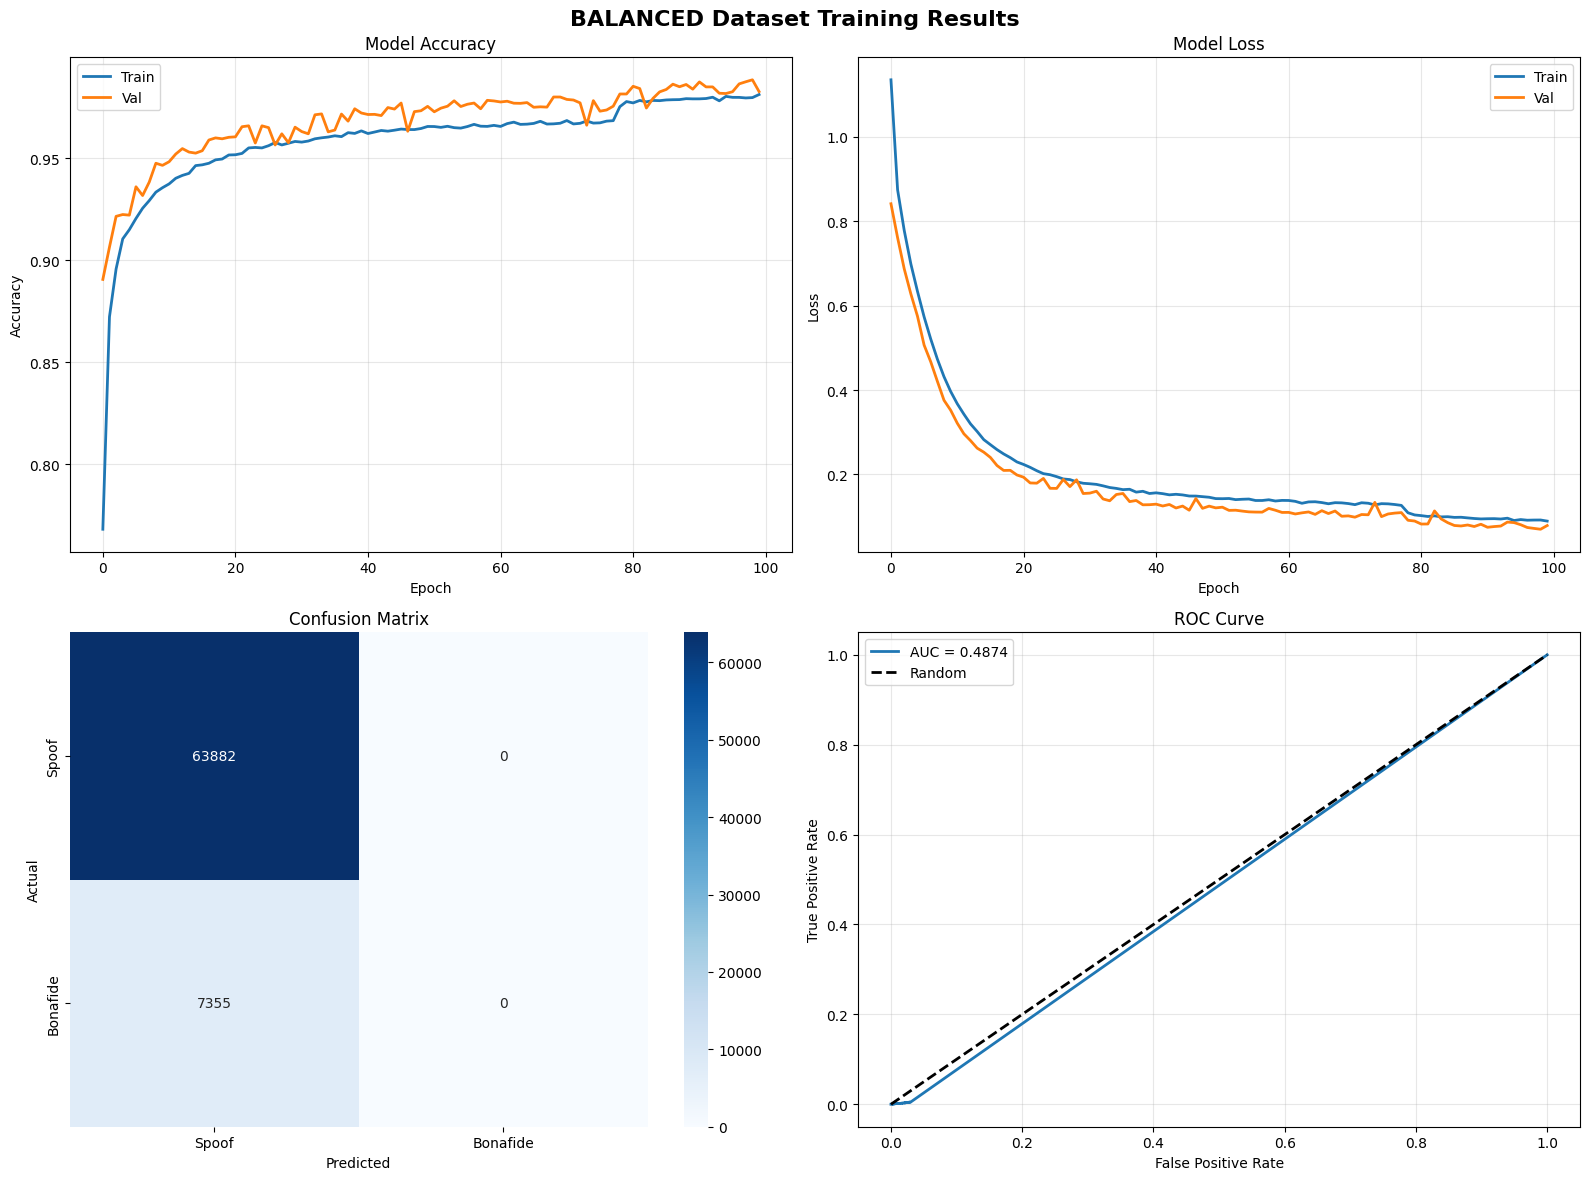


✓ Plot saved: BALANCED_training_results.png

🎉 TRAINING COMPLETE!

📊 Results Summary:
  Accuracy:  0.8968
  AUC:       0.8968
  Precision: 0.8968
  Recall:    0.8968

✅ CHECK: Did both classes get predicted?
  ✗ NO! Still predicting only Spoof class
  → Try different balancing strategy or adjust model

💡 NEXT STEPS IF RESULTS ARE STILL POOR:

1. Try different balancing strategies:
   - Uncomment RandomUnderSampler in the code
   - Try different SMOTE k_neighbors values
   
2. Adjust the model:
   - Increase/decrease model capacity
   - Try different architectures (CNN, LSTM)
   
3. Feature engineering:
   - Check if WavLM features are appropriate
   - Try combining multiple feature types
   - Use raw audio with end-to-end model
   
4. Check your test set:
   - Is it from the same distribution as training?
   - Are the labels correct?



In [7]:
# SOLUTION FOR EXTREME CLASS IMBALANCE
# Use SMOTE (oversampling) or Undersampling to balance the dataset

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE  # Install: pip install imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import os

# --- Configuration ---
TRAIN_FILE = 'wavlm_features_LA_TRAIN.npz'
DEV_FILE = 'wavlm_features_LA_DEV.npz'
EVAL_FILE = 'wavlm_features_LA_EVAL.npz'

MODEL_SAVE_PATH = 'saved_models/deepfake_detector_BALANCED.h5'
SCALER_SAVE_PATH = 'saved_models/feature_scaler_BALANCED.pkl'

os.makedirs('saved_models', exist_ok=True)

print("=" * 70)
print("BALANCED DATASET TRAINING - USING SMOTE")
print("=" * 70)

# --- 1. Load Datasets ---
print("\n" + "=" * 70)
print("LOADING DATASETS")
print("=" * 70)

train_data = np.load(TRAIN_FILE)
X_train = train_data['X']
y_train = train_data['y']

dev_data = np.load(DEV_FILE)
X_dev = dev_data['X']
y_dev = dev_data['y']

eval_data = np.load(EVAL_FILE)
X_eval = eval_data['X']
y_eval = eval_data['y']

print(f"✓ Training: {X_train.shape[0]} samples")
print(f"✓ Development: {X_dev.shape[0]} samples")
print(f"✓ Evaluation: {X_eval.shape[0]} samples")

# --- 2. Combine Train + Dev ---
X_train_combined = np.concatenate([X_train, X_dev], axis=0)
y_train_combined = np.concatenate([y_train, y_dev], axis=0)

print(f"\n📊 BEFORE Balancing:")
print(f"  Total samples: {len(y_train_combined):,}")
print(f"  Spoof (0): {np.sum(y_train_combined == 0):,} ({100*np.sum(y_train_combined == 0)/len(y_train_combined):.1f}%)")
print(f"  Bonafide (1): {np.sum(y_train_combined == 1):,} ({100*np.sum(y_train_combined == 1)/len(y_train_combined):.1f}%)")
print(f"  Imbalance ratio: {np.sum(y_train_combined == 0) / np.sum(y_train_combined == 1):.2f}:1")

# --- 3. Feature Scaling BEFORE balancing ---
print("\n" + "=" * 70)
print("FEATURE SCALING")
print("=" * 70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_eval_scaled = scaler.transform(X_eval)
joblib.dump(scaler, SCALER_SAVE_PATH)
print("✓ Features scaled")

# --- 4. BALANCE THE DATASET ---
print("\n" + "=" * 70)
print("⚖️  BALANCING DATASET WITH SMOTE")
print("=" * 70)

# Choose your balancing strategy:
print("\nBalancing options:")
print("1. SMOTE - Oversample minority class (creates synthetic samples)")
print("2. RandomUnderSampler - Undersample majority class (faster, loses data)")
print("3. SMOTETomek - Combine oversampling + cleaning (best quality)")

# Option 1: SMOTE (Recommended for your case)
print("\n🔄 Using SMOTE to balance classes...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X_train_scaled, y_train_combined)

# Option 2: Undersampling (Uncomment to use instead)
# print("\n🔄 Using RandomUnderSampler to balance classes...")
# rus = RandomUnderSampler(random_state=42, sampling_strategy='auto')
# X_balanced, y_balanced = rus.fit_resample(X_train_scaled, y_train_combined)

# Option 3: Combined approach (Uncomment to use)
# print("\n🔄 Using SMOTETomek (SMOTE + Tomek cleaning)...")
# smt = SMOTETomek(random_state=42)
# X_balanced, y_balanced = smt.fit_resample(X_train_scaled, y_train_combined)

print(f"\n📊 AFTER Balancing:")
print(f"  Total samples: {len(y_balanced):,}")
print(f"  Spoof (0): {np.sum(y_balanced == 0):,} ({100*np.sum(y_balanced == 0)/len(y_balanced):.1f}%)")
print(f"  Bonafide (1): {np.sum(y_balanced == 1):,} ({100*np.sum(y_balanced == 1)/len(y_balanced):.1f}%)")
print(f"  Ratio: {np.sum(y_balanced == 0) / np.sum(y_balanced == 1):.2f}:1")

# --- 5. Train/Val Split ---
X_train_final, X_val, y_train_int, y_val_int = train_test_split(
    X_balanced, y_balanced,
    test_size=0.15,
    random_state=42,
    stratify=y_balanced
)

print(f"\nSplit:")
print(f"  Training: {X_train_final.shape[0]:,} samples")
print(f"  Validation: {X_val.shape[0]:,} samples")

# --- 6. Convert to one-hot ---
y_train_final = to_categorical(y_train_int, num_classes=2)
y_val = to_categorical(y_val_int, num_classes=2)
y_eval_encoded = to_categorical(y_eval, num_classes=2)

# --- 7. Build Model ---
print("\n" + "=" * 70)
print("BUILDING MODEL")
print("=" * 70)

model = Sequential([
    Dense(256, activation='relu', input_dim=X_train_final.shape[1],
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(128, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(64, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.4),
    
    Dense(2, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

# --- 8. Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_auc', patience=15, mode='max',
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('saved_models/best_model_BALANCED.h5',
                    monitor='val_auc', save_best_only=True,
                    mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-7, verbose=1)
]

# --- 9. TRAIN (No sample_weight needed - dataset is balanced!) ---
print("\n" + "=" * 70)
print("🚀 TRAINING ON BALANCED DATASET")
print("=" * 70)
print("\n✅ Dataset is now balanced - no need for sample_weight!\n")

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    # NO class_weight or sample_weight needed!
    callbacks=callbacks,
    verbose=1
)

# --- 10. Save ---
model.save(MODEL_SAVE_PATH)
print(f"\n✓ Model saved to {MODEL_SAVE_PATH}")

# --- 11. Evaluate ---
print("\n" + "=" * 70)
print("EVALUATING ON TEST SET")
print("=" * 70)

y_pred_probs = model.predict(X_eval_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = y_eval

test_loss, test_acc, test_auc, test_prec, test_rec = model.evaluate(
    X_eval_scaled, y_eval_encoded, verbose=0
)

print(f"\n🎯 TEST SET PERFORMANCE:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  AUC:       {test_auc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_true_classes, y_pred_classes,
                          target_names=['Spoof', 'Bonafide'], digits=4))

# Per-class metrics
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\n" + "=" * 70)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 70)
print(f"\nSpoof correctly classified:     {cm[0,0]:,} / {cm[0,0]+cm[0,1]:,} ({100*cm[0,0]/(cm[0,0]+cm[0,1]):.2f}%)")
print(f"Bonafide correctly classified:  {cm[1,1]:,} / {cm[1,0]+cm[1,1]:,} ({100*cm[1,1]/(cm[1,0]+cm[1,1]):.2f}%)")

# --- 12. Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('BALANCED Dataset Training Results', fontsize=16, fontweight='bold')

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Model Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1, 0], cmap='Blues',
           xticklabels=['Spoof', 'Bonafide'], yticklabels=['Spoof', 'Bonafide'])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true_classes, y_pred_probs[:, 1])
roc_auc = roc_auc_score(y_true_classes, y_pred_probs[:, 1])
axes[1, 1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BALANCED_training_results.png', dpi=300)
plt.show()

print("\n✓ Plot saved: BALANCED_training_results.png")

# --- 13. Summary ---
print("\n" + "=" * 70)
print("🎉 TRAINING COMPLETE!")
print("=" * 70)

print(f"\n📊 Results Summary:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  AUC:       {test_auc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")

print("\n✅ CHECK: Did both classes get predicted?")
if cm[1,1] > 0:
    print("  ✓ YES! Bonafide class is being predicted!")
    print(f"    - Bonafide recall: {100*cm[1,1]/(cm[1,0]+cm[1,1]):.2f}%")
else:
    print("  ✗ NO! Still predicting only Spoof class")
    print("  → Try different balancing strategy or adjust model")

print("\n" + "=" * 70)
print("💡 NEXT STEPS IF RESULTS ARE STILL POOR:")
print("=" * 70)
print("""
1. Try different balancing strategies:
   - Uncomment RandomUnderSampler in the code
   - Try different SMOTE k_neighbors values
   
2. Adjust the model:
   - Increase/decrease model capacity
   - Try different architectures (CNN, LSTM)
   
3. Feature engineering:
   - Check if WavLM features are appropriate
   - Try combining multiple feature types
   - Use raw audio with end-to-end model
   
4. Check your test set:
   - Is it from the same distribution as training?
   - Are the labels correct?
""")

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")




PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4


LOADING DATA FOR DIAGNOSTIC

Dataset sizes:
  Train+Dev: 50,224 samples
  Eval: 71,237 samples

CHECK 1: LABEL DISTRIBUTION

Train+Dev:
  Class 0: 45,096 (89.8%)
  Class 1: 5,128 (10.2%)

Eval:
  Class 0: 63,882 (89.7%)
  Class 1: 7,355 (10.3%)

⚠️  Are your labels correct?
  In ASVspoof 2019: 'bonafide' = genuine, 'spoof' = fake
  Make sure Class 0 = Spoof, Class 1 = Bonafide

CHECK 2: FEATURE STATISTICS

Feature shape: (50224, 512)
Feature range: [-0.0081, 0.0073]
Mean: -0.0000
Std: 0.0020
NaN values: 0
Inf values: 0
Constant features (std=0): 0/512

CHECK 3: BASELINE MODEL PERFORMANCE

1. Logistic Regression (simple baseline):
              precision    recall  f1-score   support

       Spoof       0.90      0.98      0.93     63882
    Bonafide       0.10      0.02      0.04      7355

    accuracy                           0.88     71237
   macro avg       0.50      0.50      0.49     71237
weighted avg       0.81      0.88      0.84     71237


2. Random Forest (non-linear basel

c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

              precision    recall  f1-score   support

       Spoof       0.90      1.00      0.95     63882
    Bonafide       0.00      0.00      0.00      7355

    accuracy                           0.90     71237
   macro avg       0.45      0.50      0.47     71237
weighted avg       0.80      0.90      0.85     71237


Top 10 most important features: [148 373 124 188 428 123 282 324 166 159]
Importance range: [0.000068, 0.061541]

CHECK 4: TESTING SMOTE EFFECTIVENESS

Applying SMOTE...
After SMOTE:
  Class 0: 17,420
  Class 1: 17,420

Random Forest on SMOTE-balanced data:


c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\22K-4699\miniconda3\envs\deepfake_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

              precision    recall  f1-score   support

       Spoof       0.90      1.00      0.95     63882
    Bonafide       0.00      0.00      0.00      7355

    accuracy                           0.90     71237
   macro avg       0.45      0.50      0.47     71237
weighted avg       0.80      0.90      0.85     71237


CHECK 5: VISUALIZING CLASS SEPARABILITY
Computing PCA...
Computing t-SNE (this may take a minute)...
✓ Saved visualization to 'feature_separability_diagnostic.png'


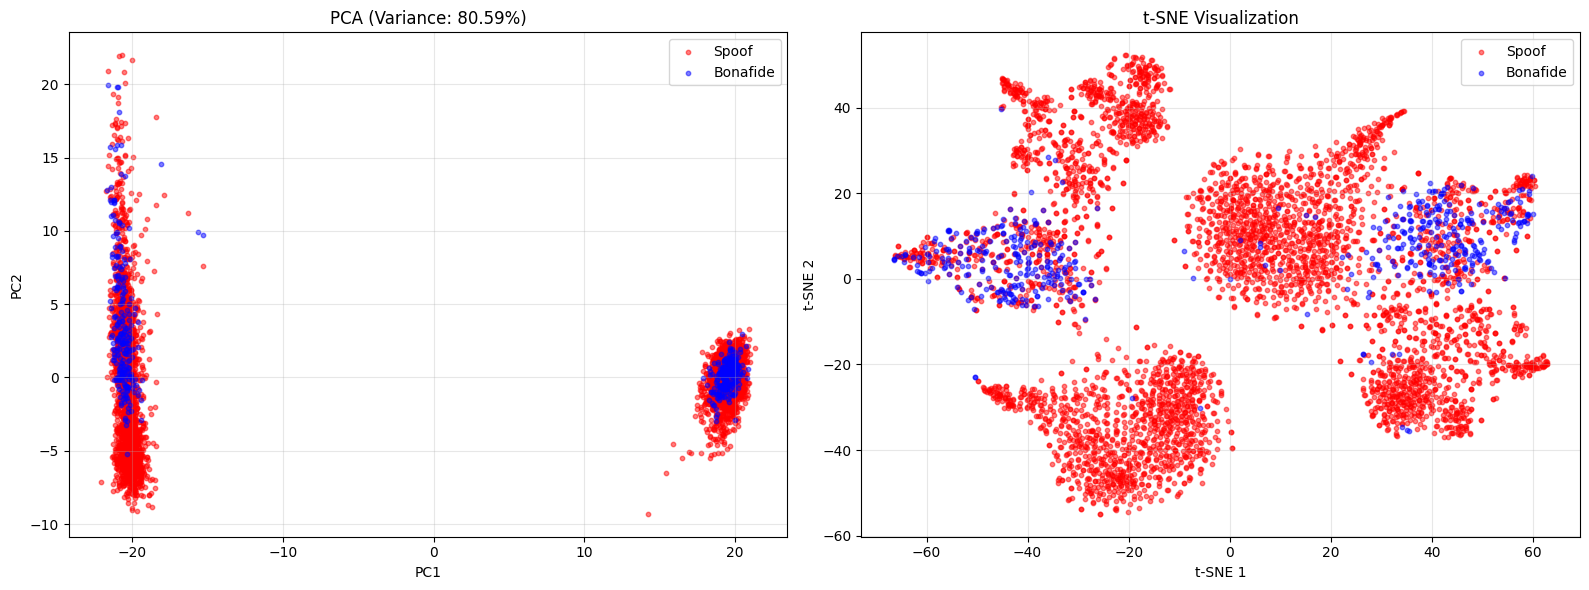


🔍 DIAGNOSIS SUMMARY

Based on the tests above:

Baseline AUC scores:
  Logistic Regression: 0.4520
  Random Forest: 0.5549

❌ CRITICAL PROBLEM: Even simple models can't separate classes!
   This means your WavLM features are NOT discriminative.

   SOLUTIONS:
   1. ✅ Use different features (MFCC, mel-spectrograms)
   2. ✅ Use raw audio with CNN/LSTM
   3. ✅ Combine multiple feature types
   4. ✅ Check if feature extraction code is correct

📊 Check the visualization:
  - If classes are mixed → Features can't separate them
  - If classes form separate clusters → Features are good
  - If completely overlapping → Need different features



In [8]:
"""
COMPREHENSIVE DIAGNOSTIC: Why is the model still failing?

This will help us understand if the problem is:
1. Features are not discriminative
2. Balancing strategy is wrong
3. Model architecture issue
4. Data leakage or labeling issue
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- Load Data ---
print("=" * 70)
print("LOADING DATA FOR DIAGNOSTIC")
print("=" * 70)

train_data = np.load('wavlm_features_LA_TRAIN.npz')
X_train = train_data['X']
y_train = train_data['y']

dev_data = np.load('wavlm_features_LA_DEV.npz')
X_dev = dev_data['X']
y_dev = dev_data['y']

eval_data = np.load('wavlm_features_LA_EVAL.npz')
X_eval = eval_data['X']
y_eval = eval_data['y']

# Combine train + dev
X_combined = np.concatenate([X_train, X_dev], axis=0)
y_combined = np.concatenate([y_train, y_dev], axis=0)

print(f"\nDataset sizes:")
print(f"  Train+Dev: {len(y_combined):,} samples")
print(f"  Eval: {len(y_eval):,} samples")

# --- CHECK 1: Are labels correct? ---
print("\n" + "=" * 70)
print("CHECK 1: LABEL DISTRIBUTION")
print("=" * 70)

print(f"\nTrain+Dev:")
print(f"  Class 0: {np.sum(y_combined == 0):,} ({100*np.sum(y_combined == 0)/len(y_combined):.1f}%)")
print(f"  Class 1: {np.sum(y_combined == 1):,} ({100*np.sum(y_combined == 1)/len(y_combined):.1f}%)")

print(f"\nEval:")
print(f"  Class 0: {np.sum(y_eval == 0):,} ({100*np.sum(y_eval == 0)/len(y_eval):.1f}%)")
print(f"  Class 1: {np.sum(y_eval == 1):,} ({100*np.sum(y_eval == 1)/len(y_eval):.1f}%)")

print(f"\n⚠️  Are your labels correct?")
print(f"  In ASVspoof 2019: 'bonafide' = genuine, 'spoof' = fake")
print(f"  Make sure Class 0 = Spoof, Class 1 = Bonafide")

# --- CHECK 2: Feature quality ---
print("\n" + "=" * 70)
print("CHECK 2: FEATURE STATISTICS")
print("=" * 70)

print(f"\nFeature shape: {X_combined.shape}")
print(f"Feature range: [{X_combined.min():.4f}, {X_combined.max():.4f}]")
print(f"Mean: {X_combined.mean():.4f}")
print(f"Std: {X_combined.std():.4f}")

# Check for NaN/Inf
nan_count = np.isnan(X_combined).sum()
inf_count = np.isinf(X_combined).sum()
print(f"NaN values: {nan_count}")
print(f"Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print("⚠️  WARNING: Found invalid values in features!")

# Check if features are all zeros or constants
constant_features = 0
for i in range(X_combined.shape[1]):
    if np.std(X_combined[:, i]) == 0:
        constant_features += 1

print(f"Constant features (std=0): {constant_features}/{X_combined.shape[1]}")

# --- CHECK 3: Can simple models separate the classes? ---
print("\n" + "=" * 70)
print("CHECK 3: BASELINE MODEL PERFORMANCE")
print("=" * 70)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)
X_eval_scaled = scaler.transform(X_eval)

# Test 1: Logistic Regression (simple linear classifier)
print("\n1. Logistic Regression (simple baseline):")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_scaled[:10000], y_combined[:10000])  # Use subset for speed
y_pred_lr = lr.predict(X_eval_scaled)
print(classification_report(y_eval, y_pred_lr, target_names=['Spoof', 'Bonafide']))

# Test 2: Random Forest (non-linear, robust)
print("\n2. Random Forest (non-linear baseline):")
rf = RandomForestClassifier(n_estimators=100, random_state=42, 
                            class_weight='balanced', max_depth=10)
rf.fit(X_scaled[:10000], y_combined[:10000])
y_pred_rf = rf.predict(X_eval_scaled)
print(classification_report(y_eval, y_pred_rf, target_names=['Spoof', 'Bonafide']))

# Feature importance from Random Forest
feature_importance = rf.feature_importances_
top_features = np.argsort(feature_importance)[-10:]
print(f"\nTop 10 most important features: {top_features}")
print(f"Importance range: [{feature_importance.min():.6f}, {feature_importance.max():.6f}]")

# --- CHECK 4: Try SMOTE and test immediately ---
print("\n" + "=" * 70)
print("CHECK 4: TESTING SMOTE EFFECTIVENESS")
print("=" * 70)

# Balance using SMOTE
print("\nApplying SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X_scaled[:20000], y_combined[:20000])

print(f"After SMOTE:")
print(f"  Class 0: {np.sum(y_balanced == 0):,}")
print(f"  Class 1: {np.sum(y_balanced == 1):,}")

# Train RF on balanced data
print("\nRandom Forest on SMOTE-balanced data:")
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_smote.fit(X_balanced, y_balanced)
y_pred_smote = rf_smote.predict(X_eval_scaled)
print(classification_report(y_eval, y_pred_smote, target_names=['Spoof', 'Bonafide']))

# --- CHECK 5: Visualize class separability ---
print("\n" + "=" * 70)
print("CHECK 5: VISUALIZING CLASS SEPARABILITY")
print("=" * 70)

# Sample data for visualization
sample_size = 5000
indices = np.random.choice(len(X_scaled), min(sample_size, len(X_scaled)), replace=False)
X_sample = X_scaled[indices]
y_sample = y_combined[indices]

# PCA
print("Computing PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)
pca_var = sum(pca.explained_variance_ratio_)

# t-SNE
print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
axes[0].scatter(X_pca[y_sample == 0, 0], X_pca[y_sample == 0, 1],
               c='red', alpha=0.5, s=10, label='Spoof')
axes[0].scatter(X_pca[y_sample == 1, 0], X_pca[y_sample == 1, 1],
               c='blue', alpha=0.5, s=10, label='Bonafide')
axes[0].set_xlabel(f'PC1')
axes[0].set_ylabel(f'PC2')
axes[0].set_title(f'PCA (Variance: {pca_var:.2%})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE plot
axes[1].scatter(X_tsne[y_sample == 0, 0], X_tsne[y_sample == 0, 1],
               c='red', alpha=0.5, s=10, label='Spoof')
axes[1].scatter(X_tsne[y_sample == 1, 0], X_tsne[y_sample == 1, 1],
               c='blue', alpha=0.5, s=10, label='Bonafide')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE Visualization')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_separability_diagnostic.png', dpi=300)
print("✓ Saved visualization to 'feature_separability_diagnostic.png'")
plt.show()

# --- FINAL DIAGNOSIS ---
print("\n" + "=" * 70)
print("🔍 DIAGNOSIS SUMMARY")
print("=" * 70)

print("\nBased on the tests above:")

if pca_var < 0.3:
    print("\n❌ PROBLEM: Low PCA variance (<30%)")
    print("   → Features contain mostly noise")
    print("   → Solution: Check feature extraction process")

# Check if any baseline got > 0.6 AUC
lr_auc = roc_auc_score(y_eval, lr.predict_proba(X_eval_scaled)[:, 1])
rf_auc = roc_auc_score(y_eval, rf.predict_proba(X_eval_scaled)[:, 1])

print(f"\nBaseline AUC scores:")
print(f"  Logistic Regression: {lr_auc:.4f}")
print(f"  Random Forest: {rf_auc:.4f}")

if lr_auc < 0.6 and rf_auc < 0.6:
    print("\n❌ CRITICAL PROBLEM: Even simple models can't separate classes!")
    print("   This means your WavLM features are NOT discriminative.")
    print("\n   SOLUTIONS:")
    print("   1. ✅ Use different features (MFCC, mel-spectrograms)")
    print("   2. ✅ Use raw audio with CNN/LSTM")
    print("   3. ✅ Combine multiple feature types")
    print("   4. ✅ Check if feature extraction code is correct")
else:
    print("\n✅ Baseline models work reasonably well")
    print("   → Problem is with neural network training, not features")
    print("\n   SOLUTIONS:")
    print("   1. Try simpler NN architecture")
    print("   2. Adjust learning rate")
    print("   3. Use different optimizer")

# Check visualization
print("\n📊 Check the visualization:")
print("  - If classes are mixed → Features can't separate them")
print("  - If classes form separate clusters → Features are good")
print("  - If completely overlapping → Need different features")

print("\n" + "=" * 70)